# Pré-Analyse et début d'analyse

### Importer les bonnes librairies et les données

In [1]:
# Import necessary libraries
import pandas as pd  # to load the dataframe
from sklearn.preprocessing import StandardScaler  # to standardize the features
from sklearn.decomposition import PCA  # to apply PCA
import seaborn as sns  # to plot the heat maps
# Import data
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_8 = scipy.io.loadmat('../data/Rat8-20130713_proces_bin5_extract.mat') # session 13 from rat 8 version trunked
data_11 = scipy.io.loadmat('../data/Rat11-20150327_proces_bin5_extract.mat') # session 27 from rat 11 version trunked

print("variables disponibles : ", data_8.keys())

def sanity_check_extract(data, rat_name="Rat?"):
    spkD = data['spk_extract_danger']['postrun'][0,0]
    spkS = data['spk_extract_safe']['postrun'][0,0]
    meta = data['metadata']

    print(rat_name)
    print("spk_danger shape (neurons x time):", spkD.shape)
    print("spk_safe   shape (neurons x time):", spkS.shape)
    print("metadata shape:", meta.shape)

    # firing rates sanity
    fr = np.mean(np.hstack([spkD, spkS]), axis=1)
    print("FR summary (Hz): min/median/max =", float(fr.min()), float(np.median(fr)), float(fr.max()))

    print("Zone length (bins) / number of laps:")
    print(len(data_8['lap_danger']['postrun'][0,0]))

    ld = data_8['lap_danger']['postrun'][0,0]

    print(type(ld))
    print("Shape:", np.shape(ld))
    print("First 20 values:", ld[:20])

sanity_check_extract(data_8, "Rat 8 (bin5_extract)")
sanity_check_extract(data_11, "Rat 11 (bin5_extract)")

variables disponibles :  dict_keys(['__header__', '__version__', '__globals__', 'cellexc', 'event', 'lap_danger', 'lap_safe', 'length_track', 'metadata', 'pos_puff', 'pos_tot_postrun', 'pos_tot_prerun', 'pos_tot_run', 'posit', 'puff_dir', 'ripl', 'spk_extract_danger', 'spk_extract_safe', 'tbin', 'zone_postrun', 'zone_prerun', 'zone_run'])
Rat 8 (bin5_extract)
spk_danger shape (neurons x time): (252, 248)
spk_safe   shape (neurons x time): (252, 112)
metadata shape: (252, 4)
FR summary (Hz): min/median/max = 0.0 0.2222222222222222 62.888888888888886
Zone length (bins) / number of laps:
1
<class 'numpy.ndarray'>
Shape: (1, 248)
First 20 values: [[ 722  723  724  725  726  727  728  729  730  731  732  733  734  735
   736  737  738  739  740  741  742  743  744  745  746  747  748  749
   750  751  752  753  754  755  756  757  758  759  760  761  762  763
   764  765  766  767  768  769  770  771  772  773  774  775  776  777
   778  779  780  781  782  783  784  785  786  787  788  789

### Visualiser les données brutes

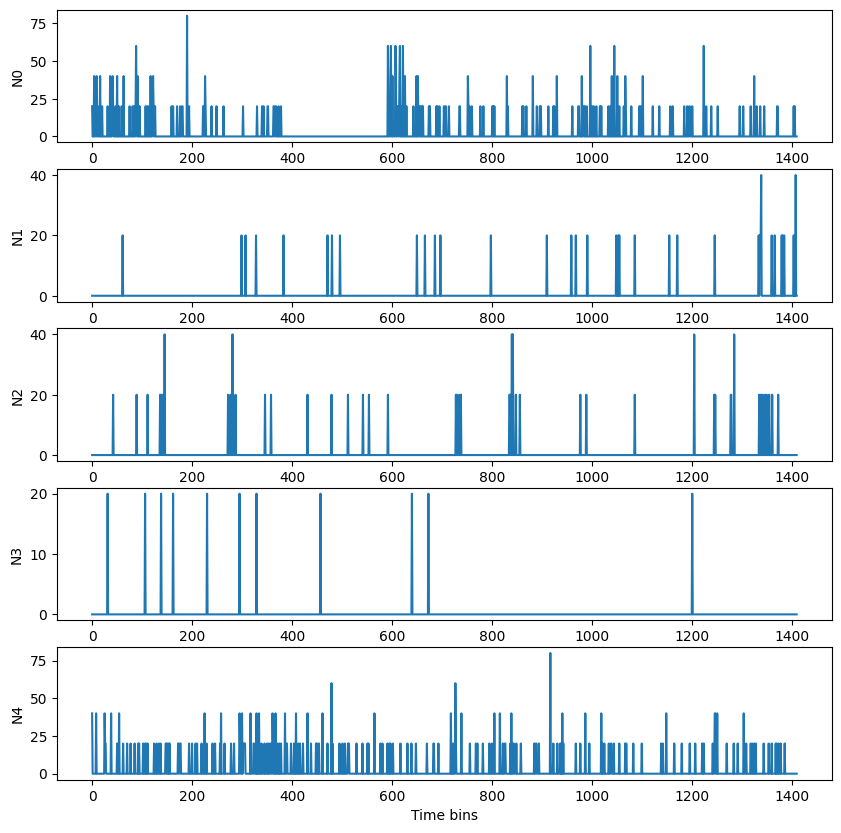

223


In [3]:
spk_danger = data_8['spk_extract_danger']['run'][0,0]  # neurones x temps
spk_safe   = data_8['spk_extract_safe']['run'][0,0]

metadata = data_8['metadata']   # neurones x 4

is_exc = metadata[:,3] == 1        # pyramidal
is_hpc = metadata[:,2] == 1        # hippocampe
is_bla = np.isin(metadata[:,2], [2,3])

exc_idx = np.where(is_exc)[0]
hpc_exc_idx = np.where(is_exc & is_hpc)[0]
bla_exc_idx = np.where(is_exc & is_bla)[0]

X = spk_danger[exc_idx, :]

plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(5,1,i+1)
    plt.plot(X[i])
    plt.ylabel(f'N{i}')
plt.xlabel('Time bins')
plt.show()

print(len(X))


### Firing rate moyen (HPC vs Amigdala)

FR mean HPC: 0.6125893950132079
FR mean Amyg: 0.4578484028246223


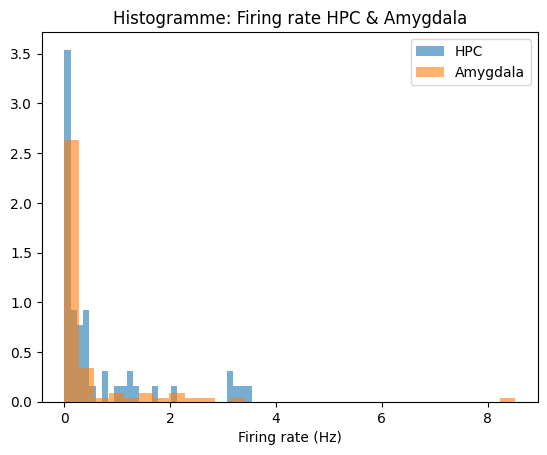

In [4]:
FR = np.mean(spk_danger, axis=1)

FR_hpc = FR[hpc_exc_idx]
FR_bla = FR[bla_exc_idx]

print('FR mean HPC:', FR_hpc.mean())
print('FR mean Amyg:', FR_bla.mean())

plt.hist(FR_hpc, bins=30, alpha=0.6, density=True, label='HPC')
plt.hist(FR_bla, bins=30, alpha=0.6, density=True, label='Amygdala')
plt.xlabel('Firing rate (Hz)')
plt.title('Histogramme: Firing rate HPC & Amygdala')
plt.legend()
plt.show()

# PCA 

- réflechir à l'interêt de la vitesse ? comment l'incorporer à tout ça et ce que ça apporte !
- bien expliquer le plot loadings (poids des neurones, neurones dominants ?)
- verifier que _extract fait ce que l'on veut et surtout utiliser le ma fonction peut-être pour faire le time_wraping
- non negative matrix ? neurones x temps x laps (condition) : il faut que le temps passé dans chaque laps soit le même! d'où le fait d'observer la variabilité des laps danger / safe (et le time wrapping)
- plot le poids de chaque neurones, mettre un seuil et isoler les neurones au dessus du seuilet visualiser l'activité durant le danger ? 

l'idée c'est que je ne veux pas dépendre du fichier _extract car je pense que ça ne marche pas exactement comme je veux... je prefererais faire appel à ma fonction qui extrait les laps autour du air_puff... je dois donc rajouter la fonction qui extrait les spikes dans laps danger et des laps saufs .


In [5]:
# ============================================================
# Goal: build spk_danger / spk_safe from *_proces_bin5.mat using the extract_loop function then run PCA (time-bins) + plots + separability + top neurons.
# Time-warping intentionally ignored here for now
# ============================================================

import numpy as np
import scipy.io
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from itertools import combinations

# ============================================================
# 1) EXTRACT functions
# ============================================================

def get_danger_direction(event_run):
    """
    Determine danger direction from event_run.
    Returns +1 (left->right), -1 (right->left), or 0 if undefined.
    """
    event_run = np.squeeze(event_run)

    reward_idx = np.where((event_run == 2) | (event_run == 3))[0]
    directions = []

    for i in range(len(reward_idx) - 1):
        i0, i1 = reward_idx[i], reward_idx[i+1]
        r0 = event_run[i0]
        r1 = event_run[i1]

        # Check if danger occurred between the two rewards
        if np.any(event_run[i0:i1] == 1):
            if r0 == 3 and r1 == 2:
                directions.append(+1)  # left -> right
            elif r0 == 2 and r1 == 3:
                directions.append(-1)  # right -> left

    if len(directions) == 0:
        return 0

    return int(np.sign(np.mean(directions)))


def extract_laps(
    pos, event, dt_ms,
    left=0.25, right=0.85,
    cancel_on_backtrack=True,
    eps=1e-12
):
    x = np.asarray(pos[0], dtype=float)
    ev = np.asarray(event[0]).astype(int)
    n = len(x)
    assert len(ev) == n

    zone = np.full(n, "C", dtype="<U1")
    zone[x <= left + eps] = "L"
    zone[x >= right - eps] = "R"
    zone[np.isnan(x)] = "N"

    laps = []
    state = None
    start_idx = None

    for i in range(n):
        if zone[i] == "N":
            continue

        if state is None:
            if i > 0:
                j = i - 1
                while j >= 0 and zone[j] == "N":
                    j -= 1
                if j >= 0 and zone[j] == "L" and zone[i] == "C":
                    state = "LR"; start_idx = i
                elif j >= 0 and zone[j] == "R" and zone[i] == "C":
                    state = "RL"; start_idx = i

        else:
            if state == "LR":
                if cancel_on_backtrack and zone[i] == "L":
                    state = None; start_idx = None; continue

                if zone[i] == "R":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[(~np.isnan(x[idx])) &
                              (x[idx] >= left - eps) &
                              (x[idx] <= right + eps)]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": +1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None; start_idx = None

            elif state == "RL":
                if cancel_on_backtrack and zone[i] == "R":
                    state = None; start_idx = None; continue

                if zone[i] == "L":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[(~np.isnan(x[idx])) &
                              (x[idx] >= left - eps) &
                              (x[idx] <= right + eps)]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": -1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None; start_idx = None

    return laps


def label_laps_with_danger(laps, danger_dir):
    for lap in laps:
        lap["is_danger"] = (lap["dir"] == danger_dir)
    return laps


# ============================================================
# 2) NEW HELPERS (puff-zone extraction + neuron selection)
# ============================================================

def estimate_pos_puff_from_run(pos_run, event_run):
    """Median x position during puff bins (event==1) in RUN."""
    x_run = np.asarray(pos_run[0], dtype=float)
    ev = np.asarray(event_run[0]).astype(int)
    puff_idx = np.where(ev == 1)[0]
    if puff_idx.size == 0:
        raise ValueError("No puff bins found in event.run == 1. Cannot estimate pos_puff.")
    return float(np.nanmedian(x_run[puff_idx]))


def split_contiguous_indices(idx):
    """Split 1D sorted indices into contiguous chunks (diff==1)."""
    idx = np.asarray(idx, dtype=int)
    if idx.size == 0:
        return []
    cuts = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[0, cuts + 1]
    ends = np.r_[cuts + 1, idx.size]
    return [idx[s:e] for s, e in zip(starts, ends)]


def select_neurons(metadata, use_regions="HB", excit_only=True):
    """
    metadata columns (0-based):
      col2: region  (1 dHPC, 2 rBLA, 3 lBLA, 4 Pir)
      col3: type    (1 pyramidal, 2 interneuron)
    """
    meta = np.asarray(metadata)
    region = meta[:, 2].astype(int)
    ntype  = meta[:, 3].astype(int)

    keep = np.ones(meta.shape[0], dtype=bool)
    if excit_only:
        keep &= (ntype == 1)

    is_hpc = (region == 1)
    is_bla = np.isin(region, [2, 3])
    is_hb  = is_hpc | is_bla

    if use_regions == "HPC":
        keep &= is_hpc
    elif use_regions == "BLA":
        keep &= is_bla
    elif use_regions == "HB":
        keep &= is_hb
    else:
        raise ValueError("use_regions must be 'HPC', 'BLA', or 'HB'")

    idx = np.where(keep)[0]
    idx_hpc = np.where((ntype == 1) & is_hpc)[0]
    idx_bla = np.where((ntype == 1) & is_bla)[0]
    return idx, idx_hpc, idx_bla


def extract_spk_danger_safe_from_proces(
    data_full,
    session="run",
    dt_ms=50,
    corridor_left=0.25,
    corridor_right=0.85,
    halfwidth_cm=20,
    track_length_cm=180,
    cancel_on_backtrack=True,
    min_bins_per_passage=2,
    eps=1e-12,
):
    """
    Build spk_danger and spk_safe (neurons x timebins) WITHOUT using _extract files.
    Uses:
      - danger_dir inferred from RUN events
      - corridor laps inferred with extract_laps() in the chosen session
      - within each lap, keeps only bins within puff zone ±20 cm

    Returns:
      spk_danger, spk_safe, info_dict
    """
    # ---- load session arrays ----
    spk_sess = data_full["spik"][session][0, 0].astype(float)   # neurons x T
    pos_sess = data_full["posit"][session][0, 0].astype(float)  # 2 x T
    event_sess = data_full["event"][session][0, 0]              # 1 x T

    # ---- load RUN arrays for danger_dir and pos_puff ----
    pos_run = data_full["posit"]["run"][0, 0].astype(float)
    event_run = data_full["event"]["run"][0, 0]

    # ---- compute danger direction + puff position ----
    danger_dir = get_danger_direction(event_run)
    pos_puff = estimate_pos_puff_from_run(pos_run, event_run)

    delta = halfwidth_cm / track_length_cm
    left_win = pos_puff - delta
    right_win = pos_puff + delta

    # ---- extract corridor laps in the chosen session ----
    laps = extract_laps(
        pos_sess, event_sess, dt_ms,
        left=corridor_left, right=corridor_right,
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps
    )
    laps = label_laps_with_danger(laps, danger_dir)

    x = np.asarray(pos_sess[0], dtype=float)

    danger_chunks = []
    safe_chunks = []
    passages = []  # debug info per extracted passage

    for lap in laps:
        idx = lap["idx"]

        inside = idx[
            (~np.isnan(x[idx])) &
            (x[idx] >= left_win - eps) &
            (x[idx] <= right_win + eps)
        ]

        if inside.size < min_bins_per_passage:
            continue

        # robust: split into contiguous puff passages
        chunks = split_contiguous_indices(inside)

        for ch in chunks:
            if ch.size < min_bins_per_passage:
                continue
            seg_spk = spk_sess[:, ch]  # neurons x L

            passages.append({
                "lap": lap["lap"],
                "dir": lap["dir"],
                "is_danger": lap["is_danger"],
                "t_start": int(ch[0]),
                "t_end": int(ch[-1]),
                "len_bins": int(ch.size),
            })

            if lap["is_danger"]:
                danger_chunks.append(seg_spk)
            else:
                safe_chunks.append(seg_spk)

    if len(danger_chunks) == 0:
        raise ValueError(f"No danger passages found in {session}. Check danger_dir / window.")
    if len(safe_chunks) == 0:
        raise ValueError(f"No safe passages found in {session}. Check danger_dir / window.")

    spk_danger = np.concatenate(danger_chunks, axis=1)
    spk_safe   = np.concatenate(safe_chunks, axis=1)

    info = {
        "session": session,
        "danger_dir": danger_dir,
        "pos_puff": pos_puff,
        "window": (left_win, right_win),
        "n_laps_total": len(laps),
        "passages": passages,
        "n_passages_total": len(passages),
        "n_passages_danger": int(np.sum([p["is_danger"] for p in passages])),
        "n_passages_safe": int(np.sum([not p["is_danger"] for p in passages])),
    }
    return spk_danger, spk_safe, info


def plot_puff_passages_sanity(data_full, info, session="run"):
    """Sanity plot: only real time bins (no continuous trajectory line)."""

    pos = data_full["posit"][session][0, 0].astype(float)
    x = np.asarray(pos[0], float)

    left, right = info["window"]
    pos_puff = info["pos_puff"]

    plt.figure(figsize=(12, 3))

    # show all valid bins as faint dots (can be commented)
    valid = ~np.isnan(x)
    plt.scatter(np.where(valid)[0], x[valid], s=5, alpha=0.15, color="gray")

    # puff window
    plt.plot(x, color="0.75", lw=1, label="x position")
    plt.axhline(left,  color="k", ls="--", lw=1)
    plt.axhline(right, color="k", ls="--", lw=1)
    plt.axhline(pos_puff, color="r", ls="--", lw=1)

    # extracted passages only
    for p in info["passages"]:
        t0, t1 = p["t_start"], p["t_end"]
        idx = np.arange(t0, t1 + 1) # comment if not dot

        col = "red" if p["is_danger"] else "green"

        plt.scatter(idx, x[idx],s=15, color=col) # if dot else uncomment :
        #plt.plot(np.arange(t0, t1 + 1), x[t0:t1 + 1], color=col, lw=2)

    plt.title(f"{session} — puff-zone passages (no interpolation)")
    plt.xlabel("time bins")
    plt.ylabel("x")
    plt.tight_layout()
    plt.show()


# ============================================================
# 3) PCA + diagnostics
# ============================================================

def fit_pca_zscore(X, n_components=10, seed=0):
    Xz = StandardScaler(with_mean=True, with_std=True).fit_transform(X)
    pca = PCA(n_components=n_components, random_state=seed)
    score = pca.fit_transform(Xz)      # (T x K)
    coeff = pca.components_.T          # (N x K) because features==neurons
    return pca, score, coeff


def plot_variance_cumsum(pca, title):
    plt.figure(figsize=(6, 4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
    plt.xlabel("PC")
    plt.ylabel("Cumulative explained variance")
    plt.ylim(0, 1.01)
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_scores_danger_safe(score, y, title, pcx=0, pcy=19):
    plt.figure(figsize=(6, 6))
    plt.scatter(score[y == 0, pcx], score[y == 0, pcy],
                s=10, alpha=0.65, color="red", label="Danger")
    plt.scatter(score[y == 1, pcx], score[y == 1, pcy],
                s=10, alpha=0.65, color="green", label="Safe")

    plt.xlabel(f"PC{pcx+1}")
    plt.ylabel(f"PC{pcy+1}")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_loadings_by_region(coeff, neuron_idx, idx_hpc, idx_bla, title, pcx=0, pcy=19):
    """
    coeff is (N_selected x K) for time-bins PCA.
    neuron_idx: selected full indices -> corresponds to coeff rows.
    idx_hpc / idx_bla: full indices (excitatory) for region coloring.
    """

    full_to_sel = {full_i: sel_i for sel_i, full_i in enumerate(neuron_idx)}
    sel_hpc = np.array([full_to_sel[i] for i in idx_hpc if i in full_to_sel], dtype=int)
    sel_bla = np.array([full_to_sel[i] for i in idx_bla if i in full_to_sel], dtype=int)

    plt.figure(figsize=(6, 6))
    if sel_hpc.size:
        plt.scatter(coeff[sel_hpc, pcx], coeff[sel_hpc, pcy], s=18, alpha=0.7, label="HPC")
    if sel_bla.size:
        plt.scatter(coeff[sel_bla, pcx], coeff[sel_bla, pcy], s=18, alpha=0.7, label="BLA")
    plt.axhline(0, lw=1, alpha=0.3)
    plt.axvline(0, lw=1, alpha=0.3)
    plt.xlabel(f"Loading PC{pcx+1}")
    plt.ylabel(f"Loading PC{pcy+1}")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def separability_cv(score, y, dims=2, seed=0):
    Xp = score[:, :dims]
    clf = LogisticRegression(max_iter=5000, class_weight="balanced")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    acc = cross_val_score(clf, Xp, y, cv=cv, scoring="accuracy")
    return acc.mean(), acc.std()


def top_neurons_by_pc(coeff, neuron_idx, metadata, pc=0, top_k=10):
    weights = np.abs(coeff[:, pc])
    order = np.argsort(weights)[::-1][:top_k]
    top_full = neuron_idx[order]
    out = []
    for sel_i, full_i in zip(order, top_full):
        out.append((int(full_i), float(coeff[sel_i, pc]), metadata[full_i, :].copy()))
    return out


def best_pc_pairs(score, y, max_pc=20, seed=0):
    results = []

    clf = LogisticRegression(max_iter=5000, class_weight="balanced")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for i, j in combinations(range(max_pc), 2):
        Xp = score[:, [i, j]]
        acc = cross_val_score(clf, Xp, y, cv=cv, scoring="accuracy").mean()
        results.append((i, j, acc))

    results.sort(key=lambda x: x[2], reverse=True)
    return results


# ============================================================
# 4) RUN EVERYTHING FOR ONE RAT
# ============================================================

def run_rat_proces_pca(
    path,
    rat_name="Rat?",
    session="run",
    dt_ms=50,
    use_regions="HB",
    excit_only=True,
    n_components=20,
    seed=0,
):
    data = scipy.io.loadmat(path)
    metadata = data["metadata"]

    # 1) extract spk_danger / spk_safe from proces file
    spk_danger, spk_safe, info = extract_spk_danger_safe_from_proces(
        data,
        session=session,
        dt_ms=dt_ms,
        corridor_left=0.25,
        corridor_right=0.85,
        halfwidth_cm=20,
        track_length_cm=180,
        cancel_on_backtrack=True,
        min_bins_per_passage=2,
    )

    # 2) sanity plot of extracted passages
    plot_puff_passages_sanity(data, info, session=session)

    # 3) select neurons (features)
    neuron_idx, idx_hpc, idx_bla = select_neurons(metadata, use_regions=use_regions, excit_only=excit_only)

    # 4) build time-bin dataset
    Xd = spk_danger[neuron_idx, :].T
    Xs = spk_safe[neuron_idx, :].T

    # concaténer d'abord
    X = np.vstack([Xd, Xs])

    # moyenne de firing rate par neurone
    mean_fr = X.mean(axis=0)

    # garder neurones suffisamment actifs
    keep = mean_fr > 0.2   # treashold to adjust (I chose a little bit randomly 0.2)

    neuron_idx = neuron_idx[keep]

    # filtrer
    X = X[:, keep]

    # labels
    y = np.concatenate([
        np.zeros(Xd.shape[0], dtype=int),
        np.ones(Xs.shape[0], dtype=int)
    ])

    # 5) PCA

    ncomp = min(n_components, X.shape[1], X.shape[0]-1)
    pca, score, coeff = fit_pca_zscore(X, n_components=ncomp, seed=seed)

    pairs = best_pc_pairs(score, y, max_pc=20)

    # prints the 5 best pairs for PCA
    print("\nTop 5 PC pairs by CV accuracy:")
    for i, j, acc in pairs[:5]:
        print(f"PC{i+1} vs PC{j+1}  ->  accuracy = {acc:.3f}")

    plt.show()

    # 6) prints
    print(f"\n=== {rat_name} | session={session} | PCA from proces_bin5 ===")
    print("danger_dir:", info["danger_dir"], "pos_puff:", info["pos_puff"], "window:", info["window"])
    print("laps total:", info["n_laps_total"])
    # print("passages danger/safe:", info["n_passages_danger"], "/", info["n_passages_safe"])
    print("danger bins:", Xd.shape[0], "safe bins:", Xs.shape[0])
    print("selected neurons:", len(neuron_idx), f"(use_regions={use_regions}, excit_only={excit_only})")
    print("explained variance first 5 PCs:", np.round(pca.explained_variance_ratio_[:5], 4))

    # 7) plots

    plot_variance_cumsum(pca, f"{rat_name} — explained variance (cumsum)")

    # Scree plot
    PC_values = np.arange(pca.n_components_) + 1
    plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
    plt.title('Scree Plot')
    plt.xlabel('Principal Component')
    plt.ylabel('Variance Explained')

    # chooses the best (better accuracy) pair PCx and PCy!
    best_i, best_j, _ = pairs[0]
    # best_i, best_j = 0,1

    plot_scores_danger_safe(
        score, y,
        f"{rat_name} — Scores (PC{best_i+1} vs PC{best_j+1})",
        pcx=best_i, pcy=best_j
    )

    plot_loadings_by_region(
        coeff, neuron_idx, idx_hpc, idx_bla,
        f"{rat_name} — Loadings (PC{best_i+1} vs PC{best_j+1})",
        pcx=best_i, pcy=best_j
    )

    # 8) separability (PC space)
    for d in [2, 5]:
        dd = min(d, score.shape[1])
        m, s = separability_cv(score, y, dims=dd, seed=seed)
        # print(f"CV accuracy logistic regression on first {dd} PCs: {m:.3f} ± {s:.3f}")

    # 9) top neurons PC1
    top = top_neurons_by_pc(coeff, neuron_idx, metadata, pc=best_i, top_k=10)
    print(f"\nTop 10 neurons by |loading| on PC{best_i+1} (full index, loading, metadata row):")
    for full_i, loading, row in top:
        print(f"  neuron {full_i:4d}  loading={loading:+.4f}  meta={row}")

    return {
        "data": data,
        "info": info,
        "spk_danger": spk_danger,
        "spk_safe": spk_safe,
        "neuron_idx": neuron_idx,
        "score": score,
        "coeff": coeff,
        "pca": pca,
        "y": y,
        "best_pc_pair": (best_i, best_j),
    }

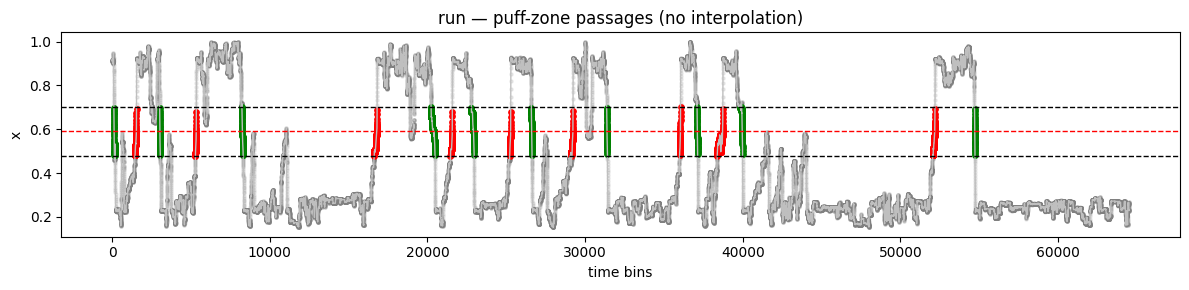


Top 5 PC pairs by CV accuracy:
PC1 vs PC13  ->  accuracy = 0.623
PC1 vs PC11  ->  accuracy = 0.619
PC1 vs PC5  ->  accuracy = 0.616
PC1 vs PC18  ->  accuracy = 0.615
PC1 vs PC9  ->  accuracy = 0.614

=== Rat 8 | session=run | PCA from proces_bin5 ===
danger_dir: 1 pos_puff: 0.5898330550918197 window: (0.4787219439807086, 0.7009441662029308)
laps total: 19
danger bins: 1179 safe bins: 883
selected neurons: 50 (use_regions=HB, excit_only=True)
explained variance first 5 PCs: [0.0348 0.0295 0.0277 0.0267 0.0264]


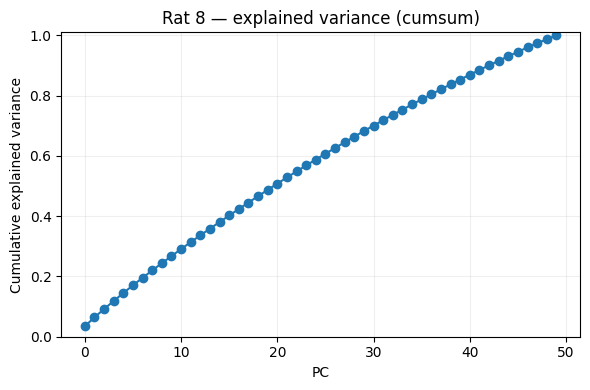

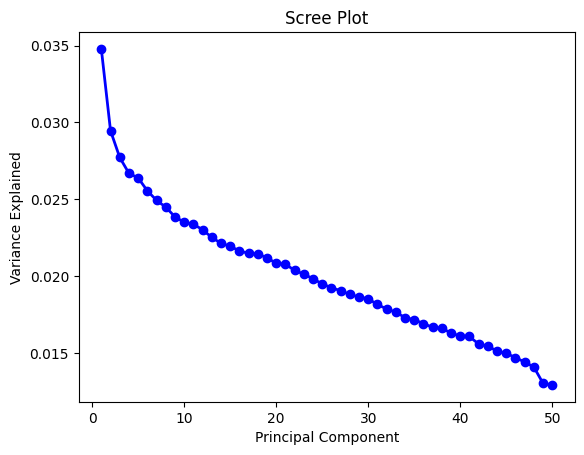

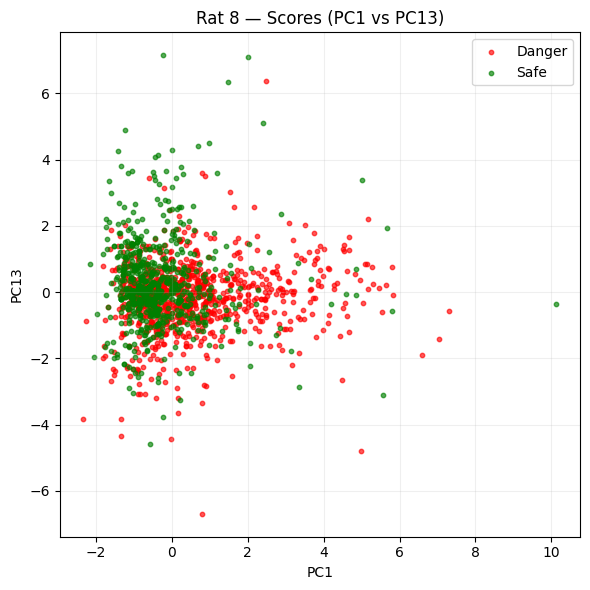

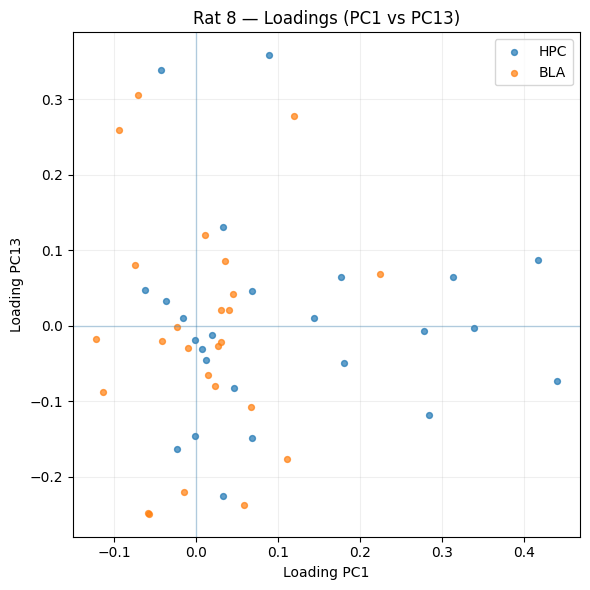


Top 10 neurons by |loading| on PC1 (full index, loading, metadata row):
  neuron   10  loading=+0.4397  meta=[11 15  1  1]
  neuron   40  loading=+0.4163  meta=[41 47  1  1]
  neuron    4  loading=+0.3389  meta=[5 9 1 1]
  neuron    2  loading=+0.3127  meta=[3 7 1 1]
  neuron   22  loading=+0.2840  meta=[23 29  1  1]
  neuron    5  loading=+0.2771  meta=[ 6 10  1  1]
  neuron   69  loading=+0.2244  meta=[70 80  3  1]
  neuron   25  loading=+0.1802  meta=[26 32  1  1]
  neuron    0  loading=+0.1758  meta=[1 3 1 1]
  neuron    9  loading=+0.1430  meta=[10 14  1  1]


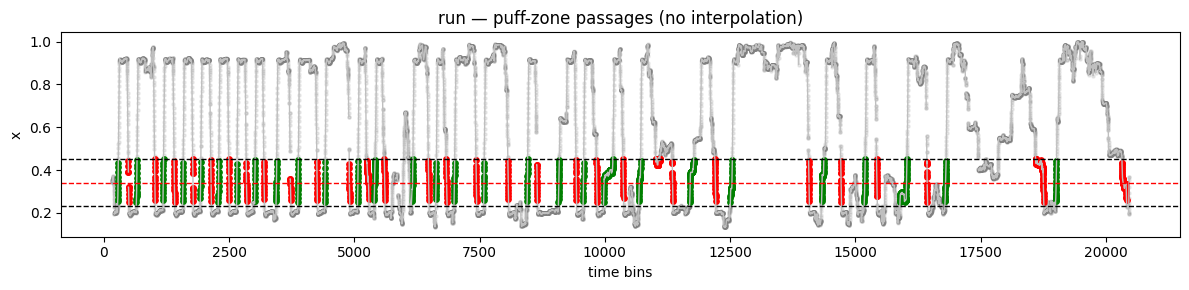


Top 5 PC pairs by CV accuracy:
PC1 vs PC4  ->  accuracy = 0.709
PC4 vs PC7  ->  accuracy = 0.676
PC4 vs PC5  ->  accuracy = 0.674
PC4 vs PC9  ->  accuracy = 0.672
PC2 vs PC4  ->  accuracy = 0.672

=== Rat 11 | session=run | PCA from proces_bin5 ===
danger_dir: -1 pos_puff: 0.34185974748086495 window: (0.23074863636975385, 0.45297085859197606)
laps total: 58
danger bins: 681 safe bins: 815
selected neurons: 90 (use_regions=HB, excit_only=True)
explained variance first 5 PCs: [0.0335 0.0233 0.0218 0.0211 0.0185]


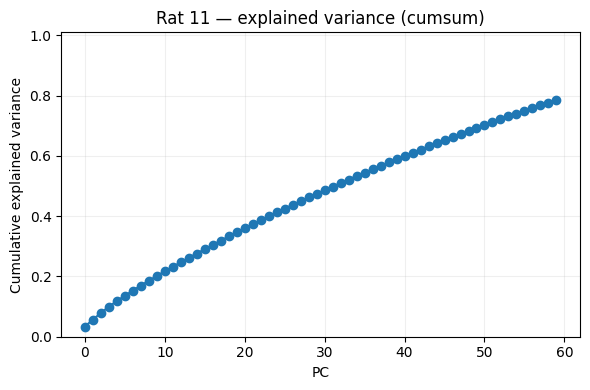

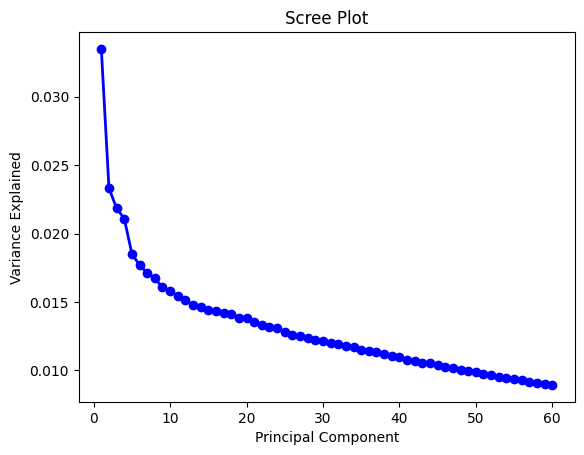

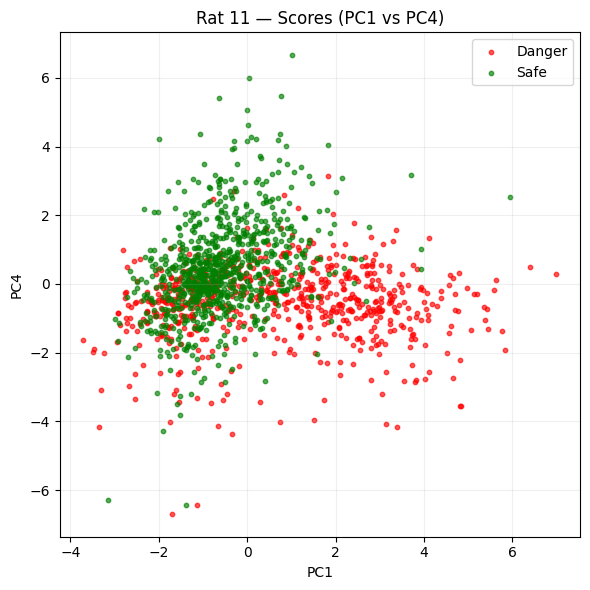

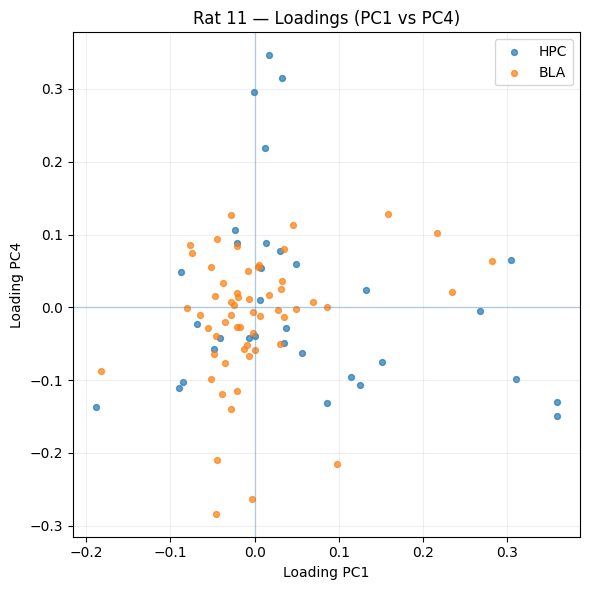


Top 10 neurons by |loading| on PC1 (full index, loading, metadata row):
  neuron  147  loading=+0.3589  meta=[148 182   1   1]
  neuron  150  loading=+0.3584  meta=[151 185   1   1]
  neuron  169  loading=+0.3104  meta=[170 204   1   1]
  neuron  205  loading=+0.3039  meta=[206 244   1   1]
  neuron  116  loading=+0.2821  meta=[117 143   3   1]
  neuron  168  loading=+0.2672  meta=[169 203   1   1]
  neuron  119  loading=+0.2345  meta=[120 146   3   1]
  neuron  109  loading=+0.2165  meta=[110 134   3   1]
  neuron  204  loading=-0.1885  meta=[205 243   1   1]
  neuron  120  loading=-0.1821  meta=[121 147   3   1]


In [6]:
# ============================================================
# 5) EXECUTE (Rat 8 + Rat 11)
# ============================================================

path_8  = "../data/Rat8-20130713_proces_bin5.mat"
path_11 = "../data/Rat11-20150327_proces_bin5.mat"

# Choose session
SESSION = "run"   # "run" or "postrun"
DT_MS = 50        # 50 ms (or 100 if *_bin1.mat)

res8  = run_rat_proces_pca(path_8,  rat_name="Rat 8",  session=SESSION, dt_ms=DT_MS, use_regions="HB", excit_only=True, n_components=60)
res11 = run_rat_proces_pca(path_11, rat_name="Rat 11", session=SESSION, dt_ms=DT_MS, use_regions="HB", excit_only=True, n_components=60)

# Analyse

In [7]:
def plot_loading_space(coeff, neuron_idx, top_full, metadata,
                       pcx, pcy, rat_name="Rat", top_k=10):

    plt.figure(figsize=(6,6))

    # color by region
    region = metadata[:,2]

    for i, n in enumerate(neuron_idx):

        x = coeff[i, pcx]
        y = coeff[i, pcy]

        if region[n] == 1:
            col = "blue"   # HPC
        elif region[n] in [2,3]:
            col = "orange" # BLA
        else:
            col = "gray"

        plt.scatter(x, y, color=col, alpha=0.6)

    # highlight top neurons
    for n in top_full:

        sel = np.where(neuron_idx == n)[0][0]

        x = coeff[sel, pcx]
        y = coeff[sel, pcy]

        plt.scatter(
            x, y,
            facecolors='none',
            edgecolors='red',
            s=200,
            linewidths=2
        )

        plt.text(x, y, str(n), fontsize=9)

    plt.axhline(0, color="black", lw=1)
    plt.axvline(0, color="black", lw=1)

    plt.xlabel(f"Loading PC{pcx+1}")
    plt.ylabel(f"Loading PC{pcy+1}")

    plt.title(f"{rat_name} — PCA loading space (top {top_k} circled)")
    plt.grid(alpha=0.3)

    plt.show()
    
def analyze_top_neurons(res, rat_name="Rat 8", top_k=10, region_for_lap_plot="BLA", n_controls=3, use_best_pair=True, plot_laps=True, seed=0):

    np.random.seed(seed)

    coeff = res["coeff"]
    neuron_idx = res["neuron_idx"]
    metadata = res["data"]["metadata"]
    info = res["info"]
    data = res["data"]

    # ----------------------------
    # 1. choose PCA axes
    # ----------------------------
    if use_best_pair:
        pcx, pcy = res["best_pc_pair"]
    else:
        pcx, pcy = 0,1

    print(f"\n{rat_name} — Using PCs: PC{pcx+1} & PC{pcy+1}")

    # ----------------------------
    # 2. select top neurons by loading strength
    # ----------------------------
    
    coeff = np.asarray(res["coeff"])
    neuron_idx = np.asarray(res["neuron_idx"])

    print("coeff shape:", coeff.shape)
    print("len(neuron_idx):", len(neuron_idx))

    if coeff.shape[0] != len(neuron_idx):
        raise ValueError(
            f"Mismatch: coeff has {coeff.shape[0]} rows but neuron_idx has length {len(neuron_idx)}. "
            "You probably need to recompute res8/res11 with the current version of run_rat_proces_pca."
        )

    strength = np.linalg.norm(coeff[:, [pcx, pcy]], axis=1)
    order = np.argsort(strength)[::-1]
    top_full = neuron_idx[order[:top_k]]

    print("top_full: ", top_full)

    fr_d_all = res["spk_danger"][neuron_idx].mean(axis=1)
    fr_s_all = res["spk_safe"][neuron_idx].mean(axis=1)
    mod_index = (fr_d_all - fr_s_all) / (fr_d_all + fr_s_all + 1e-12)

    print("mod_index: ", mod_index)

    # ----------------------------
    # 3. plot danger vs safe
    # ----------------------------
    plt.figure(figsize=(6,6))

    for n in top_full:

        fr_d = res["spk_danger"][n].mean()
        fr_s = res["spk_safe"][n].mean()

        region = metadata[n,2]

        if region == 1:
            col = "blue"
            lab = "HPC"
        elif region in [2,3]:
            col = "orange"
            lab = "BLA"
        else:
            col = "gray"
            lab = "Other"

        plt.scatter(fr_d,fr_s,color=col,s=80,alpha=0.9)
        plt.text(fr_d,fr_s,str(n),fontsize=8)

    lim = plt.xlim()
    plt.plot(lim,lim,"--",color="black")

    plt.xlabel("Danger firing rate")
    plt.ylabel("Safe firing rate")
    plt.title(f"{rat_name} — Top {top_k} neurons")
    plt.grid(alpha=0.2)

    plt.show()

    if not plot_laps:
        return top_full

    # ----------------------------
    # 4. choose region neurons for lap plot
    # ----------------------------
    region = metadata[:,2]

    if region_for_lap_plot == "BLA":
        region_neurons = np.where(np.isin(region,[2,3]))[0]

    elif region_for_lap_plot == "HPC":
        region_neurons = np.where(region==1)[0]

    else:
        raise ValueError("region_for_lap_plot must be BLA or HPC")

    selected = [n for n in top_full if n in region_neurons]

    if len(selected)==0:
        print("No selected neurons in chosen region")
        return top_full

    selected = np.array(selected[:n_controls])

    pool = np.setdiff1d(region_neurons,selected)
    controls = np.random.choice(pool,n_controls,replace=False)

    neurons = np.concatenate([selected,controls])

    print("Selected:",selected)
    print("Controls:",controls)

    # ----------------------------
    # 5. compute FR per lap
    # ----------------------------

    session = res["info"]["session"]
    spikes = data["spik"][session][0,0]
    passages = info["passages"]

    laps = sorted(list(set([p["lap"] for p in passages])))
    n_laps = len(laps)

    fr_matrix = np.zeros((len(neurons),n_laps))

    for li,lap in enumerate(laps):

        lap_pass = [p for p in passages if p["lap"]==lap]

        idx = []
        for p in lap_pass:
            idx.extend(range(p["t_start"],p["t_end"]+1))

        idx = np.array(idx)

        for ni,n in enumerate(neurons):
            fr_matrix[ni,li] = spikes[n,idx].mean()

    # ----------------------------
    # 6. detect danger laps
    # ----------------------------
    danger_laps = []

    for lap in laps:
        for p in passages:
            if p["lap"]==lap:
                danger_laps.append(p["is_danger"])
                break

    danger_laps = np.array(danger_laps)

    # ----------------------------
    # 7. plot FR over laps
    # ----------------------------
    plt.figure(figsize=(10,5))

    colors = plt.cm.tab10(np.linspace(0,1,len(neurons)))

    for i,n in enumerate(neurons):

        lw = 2.5 if n in selected else 1

        plt.plot(
            laps,
            fr_matrix[i],
            marker="o",
            linewidth=lw,
            color=colors[i],
            label=f"N{n}"
        )

    for i,is_d in enumerate(danger_laps):
        if is_d:
            plt.axvspan(i+0.5,i+1.5,color="red",alpha=0.08)

    plt.xlabel("Lap")
    plt.ylabel("Mean firing rate")
    plt.title(f"{rat_name} — FR across laps ({region_for_lap_plot})")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    # ----------------------------
    # 8. plot selected neurons (loadings)
    # ----------------------------

    plot_loading_space(
    coeff,
    neuron_idx,
    top_full,
    metadata,
    pcx,
    pcy,
    rat_name,
    top_k
)

    return top_full


Rat 8 — Using PCs: PC1 & PC13
coeff shape: (50, 50)
len(neuron_idx): 50
top_full:  [ 10  40  37  38   4   2 228  22  71   5 209]
mod_index:  [ 0.46344479 -0.02396273  0.56115945  0.3166971   0.63764599  0.54235808
 -0.24510938  0.52113445 -0.64746981  0.23009948  0.16597892  0.4452162
  0.79461123 -0.17941175  0.34631645  1.         -0.32746088 -0.2971967
 -1.          0.43528584  0.23742791  1.          0.29832484 -0.82879302
  0.22436566  0.78351083  0.01756968 -0.00858128  0.32761302  0.11963482
  0.01467746  0.05811863 -0.11312435  0.18973102 -0.220404    0.06852681
  0.44246932 -0.30151271 -0.02492834 -0.05333691  0.06560876  0.04426548
  0.53437858 -0.33738787 -0.17963195 -0.07762617 -0.28878405  0.19356388
 -0.30833252  0.05811863]


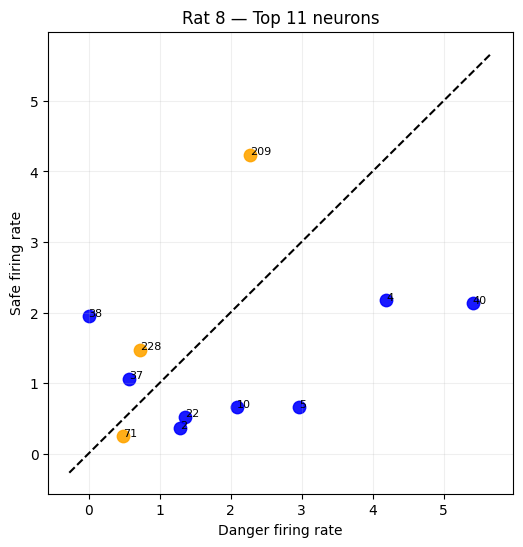

Selected: [228  71 209]
Controls: [ 62  74 213]


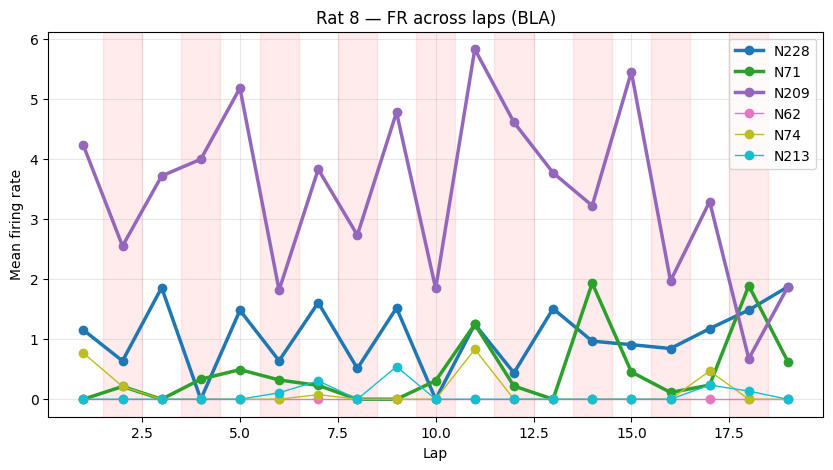

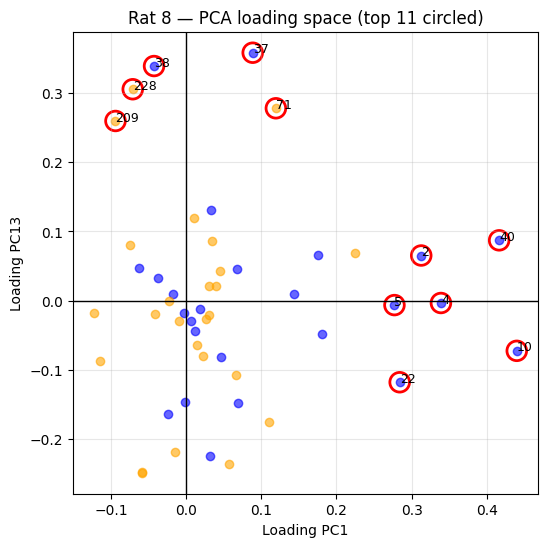


Rat 11 — Using PCs: PC1 & PC4
coeff shape: (90, 60)
len(neuron_idx): 90
top_full:  [147 150 189 169 155 205 148 116 117 168  23]
mod_index:  [-0.10413718 -0.25514657 -0.03728687  0.19701702 -0.08031597  0.03975022
 -0.5634207  -0.08829405 -0.39354479 -0.01760765  0.17902351  0.14341695
 -0.03075842  0.02304313  0.43286759 -0.18774137 -0.57984276 -0.70068677
 -0.20129361 -0.29893784 -0.02884319  0.36053002 -0.07145182 -0.1410272
 -0.16410256  0.02994996 -0.07430194 -0.4296711   0.14761793  0.46130521
  0.13253431 -0.70798997 -0.3695854   0.17902351  0.04627414 -0.16410256
  0.21440073  0.07405083  0.19870569 -0.06930269 -0.18518107  0.11631763
  0.22491117  0.08199467 -0.04101736  0.3973618  -0.01438674  0.53392078
  0.26312642 -0.31793812 -0.09377317  0.07993297  0.04097072  0.0721417
  0.04530812 -0.11244215  0.11196972  0.9510433  -0.76950339  0.65262133
  0.96005397  0.25493851 -0.48638533 -0.32031776  0.83008982 -0.06424915
  0.4962918   0.63060876 -0.08829405 -0.91511301 -0.65790

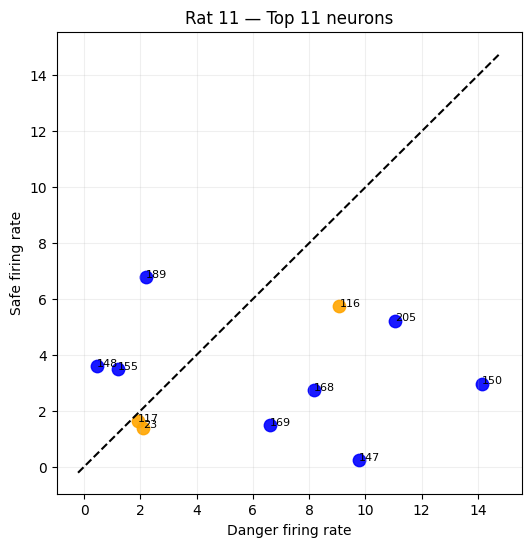

Selected: [116 117  23]
Controls: [ 19  63 140]


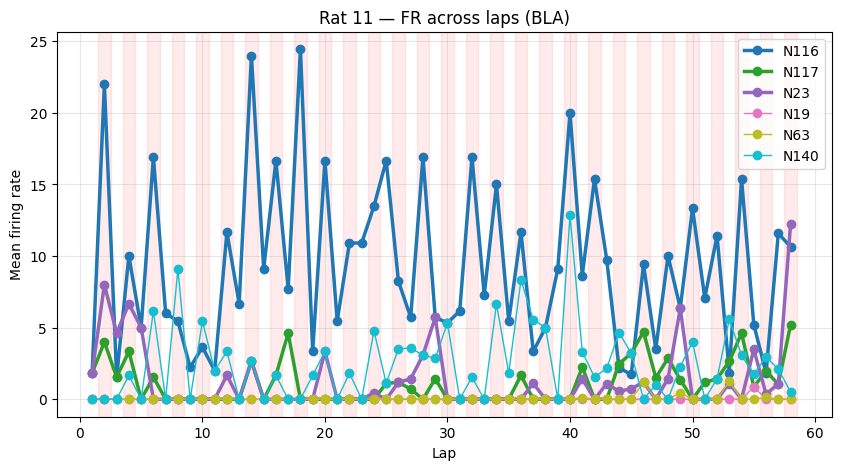

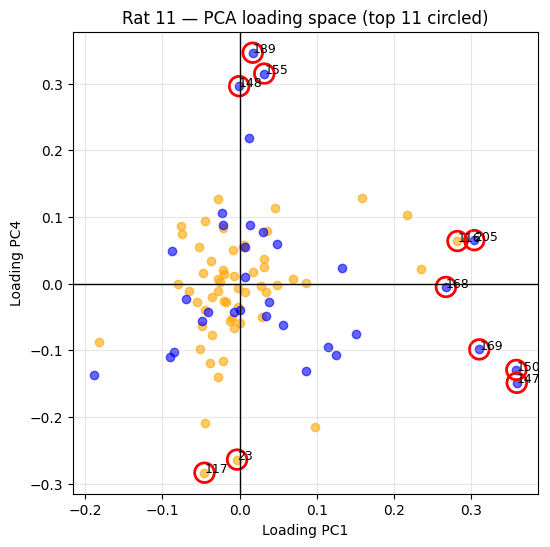

array([147, 150, 189, 169, 155, 205, 148, 116, 117, 168,  23])

In [8]:
analyze_top_neurons(
    res8,
    rat_name="Rat 8",
    top_k=11,
    region_for_lap_plot="BLA",
    n_controls=3
)

analyze_top_neurons(
    res11,
    rat_name="Rat 11",
    top_k=11,
    region_for_lap_plot="BLA",
    n_controls=3
)